In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [67]:
df = pd.read_csv('/content/drive/MyDrive/MACHINE LEARNING/Random_Forest_Project/Full_ML_Project/Dataset/Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [68]:
df.shape

(1000, 9)

In [69]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [71]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [72]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


### Handling Missing Values

In [73]:
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].astype(int)

display(df.isnull().sum())

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


### Removing 'Order_ID' Column

In [74]:
df.drop('Order_ID', axis=1, inplace=True)
display(df.head())

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1,43
1,16.42,Clear,Medium,Evening,Bike,20,2,84
2,9.52,Foggy,Low,Night,Scooter,28,1,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1,37
4,19.03,Clear,Low,Morning,Bike,16,5,68


### Exploratory Data Analysis (EDA)

#### Distribution of Target Variable: `Delivery_Time_min`

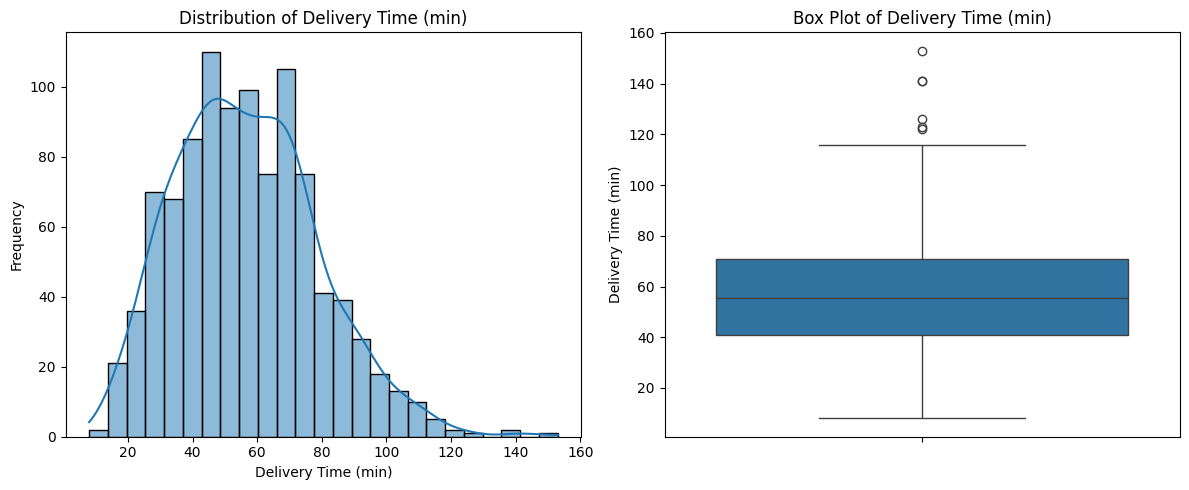

In [75]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (min)')
plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

#### Correlation Matrix

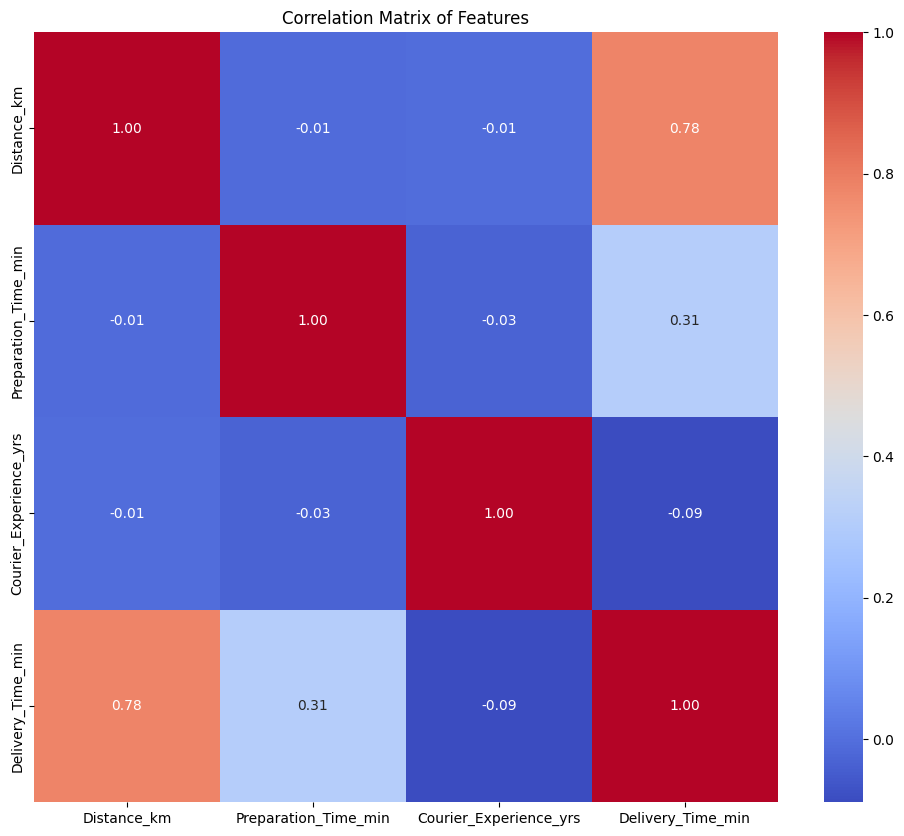

In [76]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

#### Relationship between Features and `Delivery_Time_min`

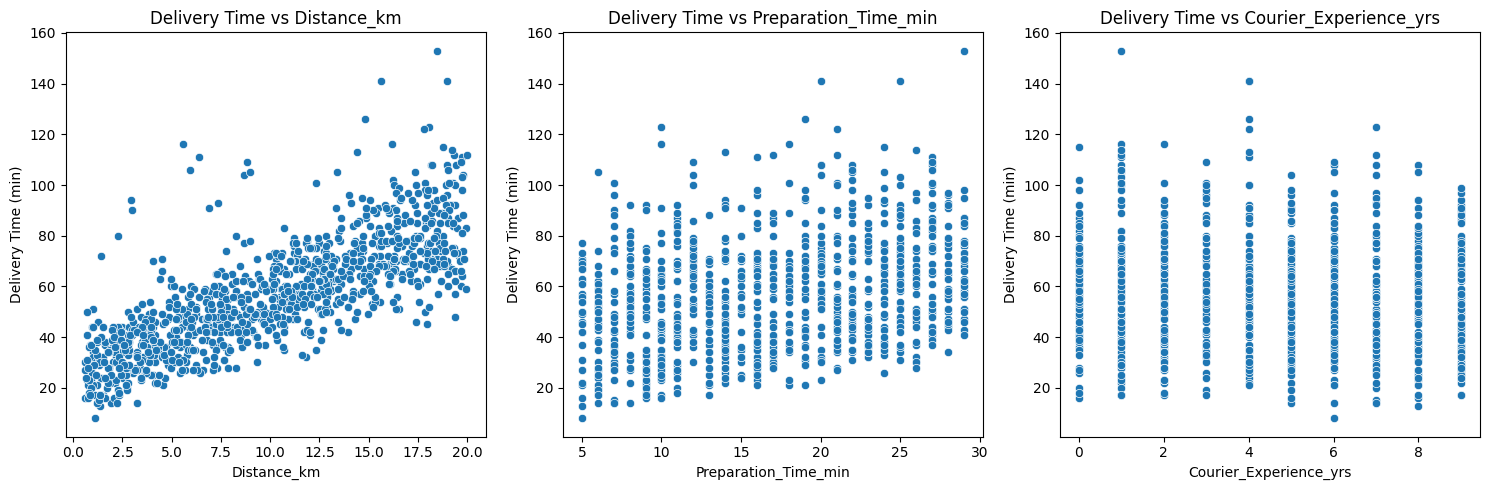

In [77]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[feature], y=df['Delivery_Time_min'])
    plt.title(f'Delivery Time vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

### Box Plots for Original Categorical Columns vs. `Delivery_Time_min`

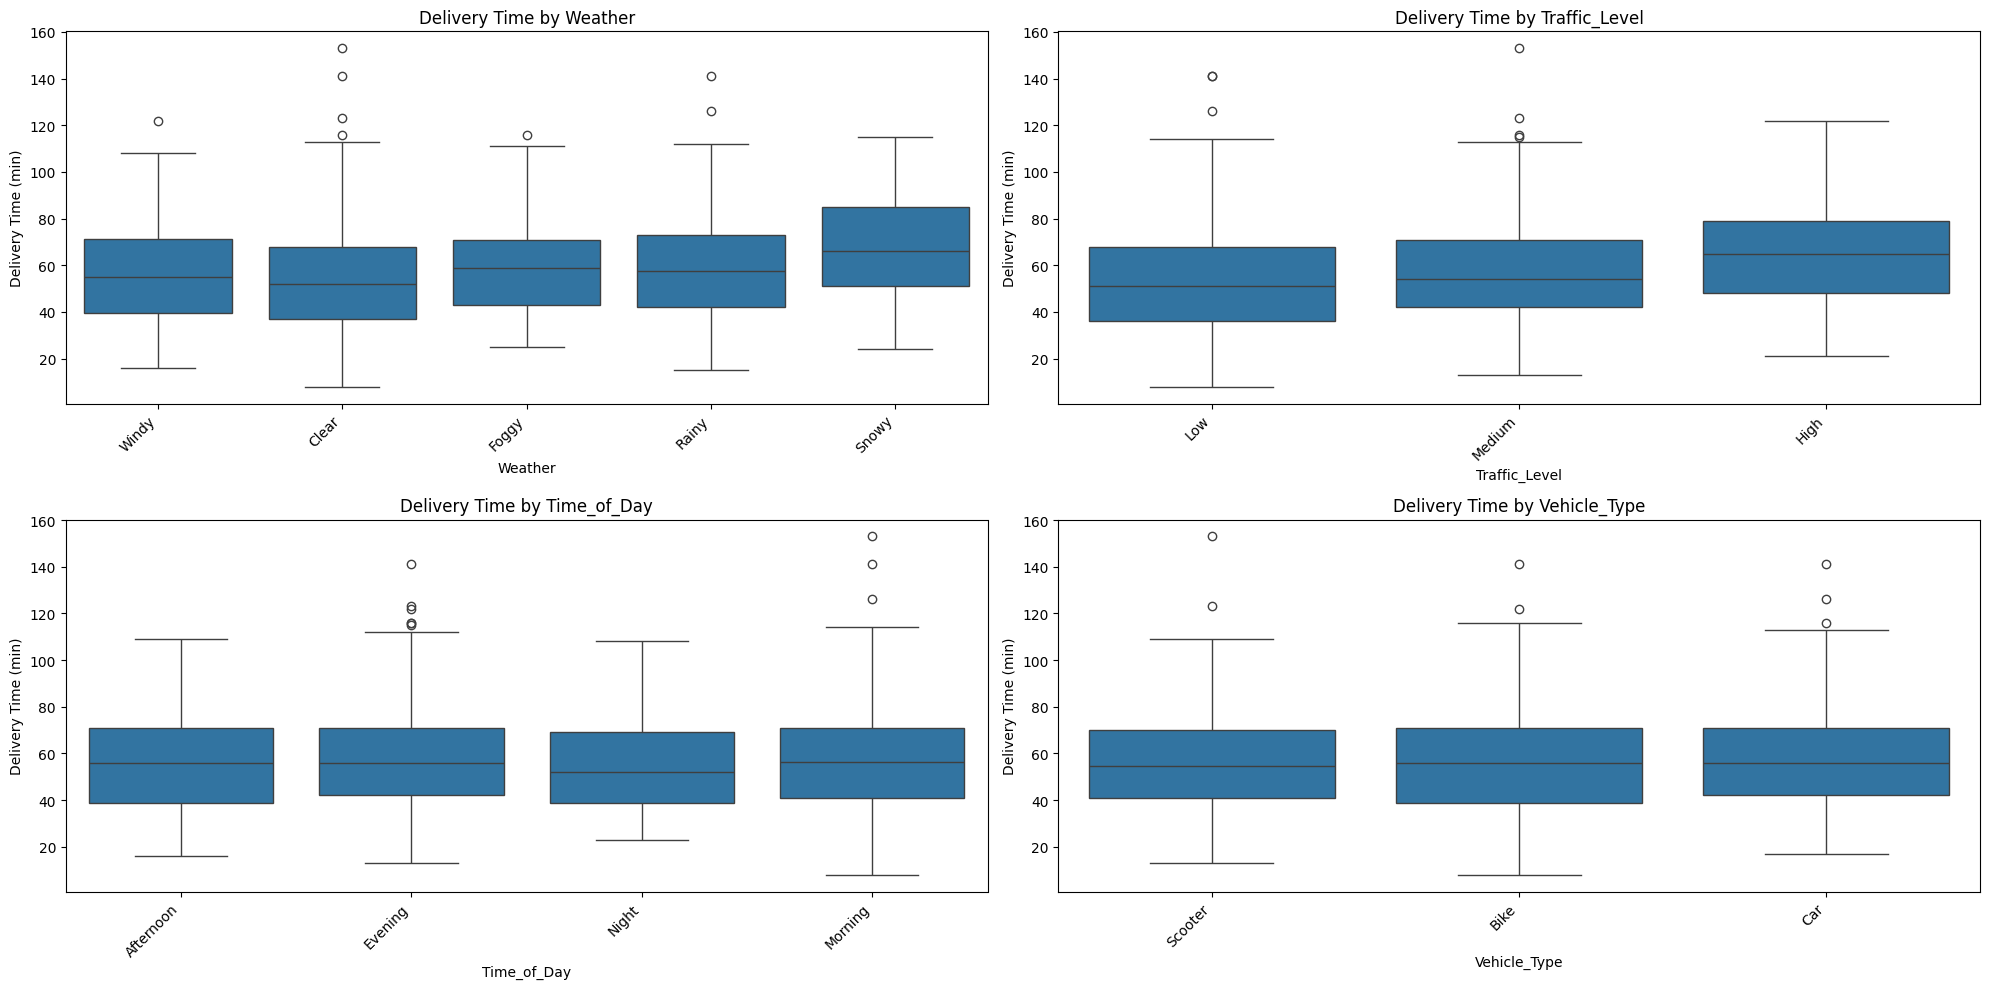

In [78]:
categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 10))
for i, col in enumerate(original_categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col], y=df['Delivery_Time_min'])
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Statistical Testing for Feature Selection

#### Pearson Correlation for Numerical Features

In [79]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

print('Pearson Correlation with Delivery_Time_min:')
for feature in numerical_features:
    correlation = df_original_cat[feature].corr(df_original_cat['Delivery_Time_min'])
    print(f'  {feature}: {correlation:.4f}')

Pearson Correlation with Delivery_Time_min:
  Distance_km: 0.7810
  Preparation_Time_min: 0.3073
  Courier_Experience_yrs: -0.0891


#### ANOVA for Categorical Features

In [80]:
from scipy.stats import f_oneway

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print('\nANOVA F-statistic and p-value for Categorical Features:')
for feature in categorical_features:
    groups = [df_original_cat['Delivery_Time_min'][df_original_cat[feature] == category] for category in df_original_cat[feature].unique()]
    f_statistic, p_value = f_oneway(*groups)
    print(f'  {feature}: F-statistic={f_statistic:.4f}, p-value={p_value:.4f}')
    if p_value < 0.05:
        print(f'    (Significant relationship with Delivery_Time_min)')
    else:
        print(f'    (No significant relationship with Delivery_Time_min)')


ANOVA F-statistic and p-value for Categorical Features:
  Weather: F-statistic=10.4991, p-value=0.0000
    (Significant relationship with Delivery_Time_min)
  Traffic_Level: F-statistic=19.7513, p-value=0.0000
    (Significant relationship with Delivery_Time_min)
  Time_of_Day: F-statistic=0.3468, p-value=0.7915
    (No significant relationship with Delivery_Time_min)
  Vehicle_Type: F-statistic=0.5894, p-value=0.5549
    (No significant relationship with Delivery_Time_min)


# Data **Preprocessing**

In [81]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original df_original_cat for subsequent steps if needed
df_encoded = df_original_cat.copy()

# Identify categorical columns (object type)
categorical_cols = df_encoded.select_dtypes(include='object').columns

print(f"Categorical columns to encode: {list(categorical_cols)}")

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Column '{col}' encoded with {len(le.classes_)} unique classes.")

display(df_encoded.head())
display(df_encoded.info())

Categorical columns to encode: ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
Column 'Weather' encoded with 5 unique classes.
Column 'Traffic_Level' encoded with 3 unique classes.
Column 'Time_of_Day' encoded with 4 unique classes.
Column 'Vehicle_Type' encoded with 3 unique classes.


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1,43
1,16.42,0,2,1,0,20,2,84
2,9.52,1,1,3,2,28,1,59
3,7.44,2,2,0,2,5,1,37
4,19.03,0,1,2,0,16,5,68


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   int64  
 2   Traffic_Level           1000 non-null   int64  
 3   Time_of_Day             1000 non-null   int64  
 4   Vehicle_Type            1000 non-null   int64  
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   int64  
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 62.6 KB


None

### Data Splitting for Model Training

Before training a model, we need to separate the features (independent variables, X) from the target variable (dependent variable, y). In this case, `Delivery_Time_min` is our target. Then, we split the data into training and testing sets to evaluate the model's performance on unseen data.

In [82]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Delivery_Time_min', axis=1)
y = df_encoded['Delivery_Time_min']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)


### Model Training: DecisionTreeRegressor (Default Parameters)

Let's train a `DecisionTreeRegressor` model using its default parameters to predict delivery times. Decision trees are simpler and more interpretable than Random Forests, and it will be interesting to compare their performance.

In [83]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model with default parameters
dtree_model = DecisionTreeRegressor(random_state=42) # Set random_state for reproducibility

# Train the model on the training data
dtree_model.fit(X_train, y_train)

print("DecisionTreeRegressor model trained successfully with default parameters.")

DecisionTreeRegressor model trained successfully with default parameters.


### Model Evaluation: DecisionTreeRegressor

Now, let's evaluate the trained `DecisionTreeRegressor` model using several regression metrics to understand its performance.

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred_dtree = dtree_model.predict(X_test)

# Calculate evaluation metrics
mae_dtree = mean_absolute_error(y_test, y_pred_dtree)
mse_dtree = mean_squared_error(y_test, y_pred_dtree)
rmse_dtree = np.sqrt(mse_dtree)
r2_dtree = r2_score(y_test, y_pred_dtree)

print(f"DecisionTreeRegressor - Mean Absolute Error (MAE): {mae_dtree:.2f}")
print(f"DecisionTreeRegressor - Mean Squared Error (MSE): {mse_dtree:.2f}")
print(f"DecisionTreeRegressor - Root Mean Squared Error (RMSE): {rmse_dtree:.2f}")
print(f"DecisionTreeRegressor - R-squared (R2) Score: {r2_dtree:.2f}")

DecisionTreeRegressor - Mean Absolute Error (MAE): 10.56
DecisionTreeRegressor - Mean Squared Error (MSE): 226.82
DecisionTreeRegressor - Root Mean Squared Error (RMSE): 15.06
DecisionTreeRegressor - R-squared (R2) Score: 0.49


### Model Training & Evaluation: RandomForestRegressor (Default Parameters)

Let's train a `RandomForestRegressor` with default parameters to see how an ensemble model performs compared to our single `DecisionTreeRegressor`.

In [85]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"RandomForestRegressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"RandomForestRegressor - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"RandomForestRegressor - R-squared (R2) Score: {r2_rf:.2f}")

RandomForestRegressor - Mean Absolute Error (MAE): 7.06
RandomForestRegressor - Mean Squared Error (MSE): 100.12
RandomForestRegressor - Root Mean Squared Error (RMSE): 10.01
RandomForestRegressor - R-squared (R2) Score: 0.78


### Hyperparameter Tuning: RandomForestRegressor

We will use `GridSearchCV` to systematically test different combinations of hyperparameters for our Random Forest model to optimize its accuracy.

In [86]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator and parameters
best_rf_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


### Evaluating the Optimized RandomForestRegressor Model

Now, let's evaluate our tuned model on the test dataset to see the improved performance metrics.

In [87]:
# Make predictions using the best model
y_pred_best_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"Tuned RandomForestRegressor - Mean Absolute Error (MAE): {mae_best_rf:.2f}")
print(f"Tuned RandomForestRegressor - Mean Squared Error (MSE): {mse_best_rf:.2f}")
print(f"Tuned RandomForestRegressor - Root Mean Squared Error (RMSE): {rmse_best_rf:.2f}")
print(f"Tuned RandomForestRegressor - R-squared (R2) Score: {r2_best_rf:.2f}")

Tuned RandomForestRegressor - Mean Absolute Error (MAE): 6.93
Tuned RandomForestRegressor - Mean Squared Error (MSE): 98.44
Tuned RandomForestRegressor - Root Mean Squared Error (RMSE): 9.92
Tuned RandomForestRegressor - R-squared (R2) Score: 0.78


### Exporting Model and Preprocessors

To build a frontend, we need to save the model and the specific label encoders used for categorical features. We'll use the `pickle` library for this.

In [88]:
import pickle

# Save the best Random Forest model
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)

# We need to save the label encoders for each categorical column
# Let's re-run the encoding loop slightly differently to store the encoders in a dictionary
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_original_cat[col].fillna(df_original_cat[col].mode()[0], inplace=True)
    le.fit(df_original_cat[col])
    encoders[col] = le

# Save the dictionary of encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Pickle files created successfully:")
print("- best_rf_model.pkl")
print("- label_encoders.pkl")

Pickle files created successfully:
- best_rf_model.pkl
- label_encoders.pkl
